Voici le notebook d'application de la théorie des valeurs extrêmes sur le jeu de données NBA.

## 1 Import/Initialisation

Je reprends ici principalement le code du nba_api.ipynb afin de définir les différentes fonctions d'import etc

In [ ]:
!pip install nba_api scipy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
from scipy.stats import genextreme, genpareto


from nba_api.stats.endpoints import (
    leaguegamefinder,
    boxscoretraditionalv2,
    playbyplayv3,
    teamgamelog,
)
from nba_api.stats.static import teams, players

from utils import nba_request_with_retry, get_team_id ,get_box, get_extended_pbp, get_blowout_games_and_scores, analysis_extreme_run, fit_gev_distribution, get_pbp, get_games_played, point_filter1, point_filter2,fetch_pbp_for_games, SLEEP

### Données anecdotiques

In [ ]:
# Toutes les équipes NBA
all_teams = teams.get_teams()
df_teams = pd.DataFrame(all_teams)
print(f"Nombre d'équipes : {len(df_teams)}")
df_teams.head(10)

Nombre d'équipes : 30


,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966
5,1610612742,Dallas Mavericks,DAL,Mavericks,Dallas,Texas,1980
6,1610612743,Denver Nuggets,DEN,Nuggets,Denver,Colorado,1976
7,1610612744,Golden State Warriors,GSW,Warriors,San Francisco,California,1946
8,1610612745,Houston Rockets,HOU,Rockets,Houston,Texas,1967
9,1610612746,Los Angeles Clippers,LAC,Clippers,Los Angeles,California,1970


In [ ]:
gsw = get_team_id("Golden State Warriors")
bos = get_team_id("Boston Celtics")
print("Golden State Warriors :", gsw)
print("Boston Celtics        :", bos)

Golden State Warriors : {'id': 1610612744, 'full_name': 'Golden State Warriors', 'abbreviation': 'GSW', 'nickname': 'Warriors', 'city': 'San Francisco', 'state': 'California', 'year_founded': 1946}
Boston Celtics        : {'id': 1610612738, 'full_name': 'Boston Celtics', 'abbreviation': 'BOS', 'nickname': 'Celtics', 'city': 'Boston', 'state': 'Massachusetts', 'year_founded': 1946}


In [ ]:
SEASON = "2023-24"
TEAM_ID = gsw["id"]  # Golden State Warriors

df_games = get_games_played(TEAM_ID, SEASON)
print(f"Matchs récupérés : {len(df_games)}")
df_games[["Game_ID", "GAME_DATE", "MATCHUP", "WL", "PTS"]].head(10)

Tentative 1/4 échouée (ReadTimeout). Nouvelle tentative dans 3s…
Tentative 2/4 échouée (ReadTimeout). Nouvelle tentative dans 6s…
Tentative 3/4 échouée (ReadTimeout). Nouvelle tentative dans 12s…


ReadTimeout: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=60)

In [ ]:
# Sélectionner un match précis pour la suite (1er match de la liste)
GAME_ID = df_games["Game_ID"].iloc[0]
print(f"Match sélectionné : {df_games['MATCHUP'].iloc[0]}  —  {df_games['GAME_DATE'].iloc[0]}")
print(f"Game ID           : {GAME_ID}")

Match sélectionné : GSW vs. UTA  —  APR 14, 2024
Game ID           : 0022301198


In [ ]:
box = get_box(game_id = GAME_ID)

df_players_box = box.get_data_frames()[0]
df_teams_box   = box.get_data_frames()[1]

cols_joueur = ["TEAM_ABBREVIATION", "PLAYER_NAME", "MIN", "PTS", "REB", "AST", "STL", "BLK", "TO", "PLUS_MINUS"]
print("=== Box Score Joueurs ===")
df_players_box[cols_joueur].dropna(subset=["MIN"])


=== Box Score Joueurs ===


,TEAM_ABBREVIATION,PLAYER_NAME,MIN,PTS,REB,AST,STL,BLK,TO,PLUS_MINUS
0,UTA,Taylor Hendricks,41:11,16.0,8.0,2.0,3.0,1.0,1.0,2.0
1,UTA,Luka Samanic,28:57,14.0,5.0,2.0,1.0,0.0,7.0,-9.0
2,UTA,Omer Yurtseven,29:48,11.0,18.0,2.0,0.0,0.0,2.0,1.0
3,UTA,Keyonte George,20:08,21.0,1.0,4.0,0.0,0.0,1.0,13.0
4,UTA,Johnny Juzang,19:09,8.0,1.0,2.0,0.0,0.0,0.0,13.0
5,UTA,Brice Sensabaugh,28:51,14.0,3.0,0.0,1.0,0.0,5.0,-20.0
6,UTA,Micah Potter,21:21,10.0,8.0,1.0,0.0,2.0,1.0,-2.0
7,UTA,Kira Lewis Jr.,27:52,13.0,3.0,3.0,1.0,0.0,1.0,-20.0
8,UTA,Darius Bazley,6:49,2.0,0.0,0.0,0.0,1.0,0.0,-9.0
9,UTA,Kenneth Lofton Jr.,15:54,7.0,1.0,6.0,0.0,1.0,1.0,-4.0


In [ ]:
print("=== Box Score Équipes ===")
df_teams_box[["TEAM_ABBREVIATION", "PTS", "FG_PCT", "FG3_PCT", "FT_PCT", "REB", "AST", "STL", "BLK", "TO"]]

=== Box Score Équipes ===


,TEAM_ABBREVIATION,PTS,FG_PCT,FG3_PCT,FT_PCT,REB,AST,STL,BLK,TO
0,UTA,116,0.517,0.412,0.625,48,22,6,5,19
1,GSW,123,0.479,0.326,0.826,42,35,10,6,9


In [ ]:
df_pbp = get_pbp(game_id = GAME_ID)
df_pbp.head(10)

Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']


,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId
0,0022301198,2,PT12M00.00S,1,0,,0,,,0,0,0,,0,0,0,0,,Start of 1st Period (3:42 PM EST),period,start,0,0,1
1,0022301198,4,PT12M00.00S,1,1610612744,GSW,1631218,Jackson-Davis,T. Jackson-Davis,0,0,0,,0,,,0,h,Jump Ball Jackson-Davis vs. Yurtseven: Tip to ...,Jump Ball,,1,0,2
2,0022301198,7,PT11M39.00S,1,1610612762,UTA,1630209,Yurtseven,O. Yurtseven,-48,11,5,Made,1,0,2,2,v,Yurtseven 5' Hook Shot (2 PTS) (Hendricks 1 AST),Made Shot,Hook Shot,1,2,3
3,0022301198,9,PT11M22.00S,1,1610612744,GSW,203952,Wiggins,A. Wiggins,-25,211,21,Made,1,2,2,4,h,Wiggins 21' Step Back Jump Shot (2 PTS) (Paul ...,Made Shot,Step Back Jump shot,1,2,4
4,0022301198,10,PT11M02.00S,1,1610612762,UTA,1630209,Yurtseven,O. Yurtseven,0,0,0,,0,,,0,v,Yurtseven Double Dribble Turnover (P1.T1),Turnover,Double Dribble,1,0,5
5,0022301198,11,PT10M51.00S,1,1610612744,GSW,203952,Wiggins,A. Wiggins,103,151,18,Missed,1,,,0,h,MISS Wiggins 18' Pullup Jump Shot,Missed Shot,Pullup Jump shot,1,2,6
6,0022301198,12,PT10M45.00S,1,1610612762,UTA,1630209,Yurtseven,O. Yurtseven,0,0,0,,0,,,0,v,Yurtseven REBOUND (Off:0 Def:1),Rebound,Unknown,1,0,7
7,0022301198,13,PT10M39.00S,1,1610612762,UTA,1641718,George,K. George,27,11,3,Made,1,2,4,6,v,George 3' Driving Layup (2 PTS),Made Shot,Driving Layup Shot,1,2,8
8,0022301198,14,PT10M23.00S,1,1610612744,GSW,202691,Thompson,K. Thompson,124,246,28,Missed,1,,,0,h,MISS Thompson 28' 3PT Jump Shot,Missed Shot,Jump Shot,1,3,9
9,0022301198,15,PT10M19.00S,1,1610612762,UTA,1629677,Samanic,L. Samanic,0,0,0,,0,,,0,v,Samanic REBOUND (Off:0 Def:1),Rebound,Unknown,1,0,10


In [ ]:
df = get_extended_pbp(game_id = GAME_ID)

print("Aperçu enrichi :")
df[["ELAPSED_MINUTES", "period", "clock", "description",
    "SCORE_HOME", "SCORE_VISITOR", "SCOREMARGIN_FF"]].dropna(
    subset=["ELAPSED_MINUTES"]
).head(15)

Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Aperçu enrichi :


,ELAPSED_MINUTES,period,clock,description,SCORE_HOME,SCORE_VISITOR,SCOREMARGIN_FF
0,0.000000,1,PT12M00.00S,Start of 1st Period (3:42 PM EST),0.0,0.0,0.0
1,0.000000,1,PT12M00.00S,Jump Ball Jackson-Davis vs. Yurtseven: Tip to ...,0.0,0.0,0.0
2,0.350000,1,PT11M39.00S,Yurtseven 5' Hook Shot (2 PTS) (Hendricks 1 AST),0.0,2.0,-2.0
3,0.633333,1,PT11M22.00S,Wiggins 21' Step Back Jump Shot (2 PTS) (Paul ...,2.0,2.0,0.0
4,0.966667,1,PT11M02.00S,Yurtseven Double Dribble Turnover (P1.T1),2.0,2.0,0.0
5,1.150000,1,PT10M51.00S,MISS Wiggins 18' Pullup Jump Shot,2.0,2.0,0.0
6,1.250000,1,PT10M45.00S,Yurtseven REBOUND (Off:0 Def:1),2.0,2.0,0.0
7,1.350000,1,PT10M39.00S,George 3' Driving Layup (2 PTS),2.0,4.0,-2.0
8,1.616667,1,PT10M23.00S,MISS Thompson 28' 3PT Jump Shot,2.0,4.0,-2.0
9,1.683333,1,PT10M19.00S,Samanic REBOUND (Off:0 Def:1),2.0,4.0,-2.0


In [ ]:
# Récupérer les noms des deux équipes depuis le box score
home_team = df_teams_box.iloc[0]["TEAM_ABBREVIATION"]
away_team = df_teams_box.iloc[1]["TEAM_ABBREVIATION"]

In [ ]:
runs = point_filter1(game_id = GAME_ID)

# Top 10 des plus grands runs
top_runs = runs.sort_values("pts", ascending=False).head(10)
print("Top 10 des runs du match :")
top_runs[["SCORER", "pts", "start_min", "end_min", "n_events"]].rename(
    columns={"SCORER":"Équipe","pts":"Points marqués","start_min":"Début (min)",
             "end_min":"Fin (min)","n_events":"Nb actions"}
).round(2)

Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Top 10 des runs du match :


,Équipe,Points marqués,Début (min),Fin (min),Nb actions
51,HOME,12.0,35.47,36.82,6
28,VISITOR,11.0,20.85,22.43,5
3,HOME,10.0,2.05,3.93,4
21,HOME,9.0,14.73,15.98,3
36,VISITOR,8.0,26.33,27.38,3
31,HOME,7.0,23.58,24.13,4
62,VISITOR,7.0,41.78,42.57,3
47,HOME,6.0,31.68,32.98,4
67,HOME,6.0,45.47,47.02,4
29,HOME,6.0,22.75,23.20,3


## 2 Réponses aux questions

### Q1 — Quelle est la probabilité d'observer un run extrême ? (niveau brut ou niveau score pondéré)

#### Définition run extrême + visualisation des distributions

In [ ]:
import numpy as np

# Define what an 'extreme run' means. For example, runs with >= 8 points.
extreme_threshold = 8

# Filter runs that meet the extreme threshold
extreme_runs = runs[runs['pts'] >= extreme_threshold]

# Calculate the total number of runs observed
total_runs_count = len(runs)

# Calculate the number of extreme runs
extreme_runs_count = len(extreme_runs)

# Calculate the probability of an extreme run
probability_extreme_run = extreme_runs_count / total_runs_count if total_runs_count > 0 else 0

print(f"Total runs analyzed: {total_runs_count}")
print(f"Number of extreme runs (>= {extreme_threshold} points): {extreme_runs_count}")
print(f"Probability of observing an extreme run: {probability_extreme_run:.4f}")

Total runs analyzed: 68
Number of extreme runs (>= 8 points): 5
Probability of observing an extreme run: 0.0735


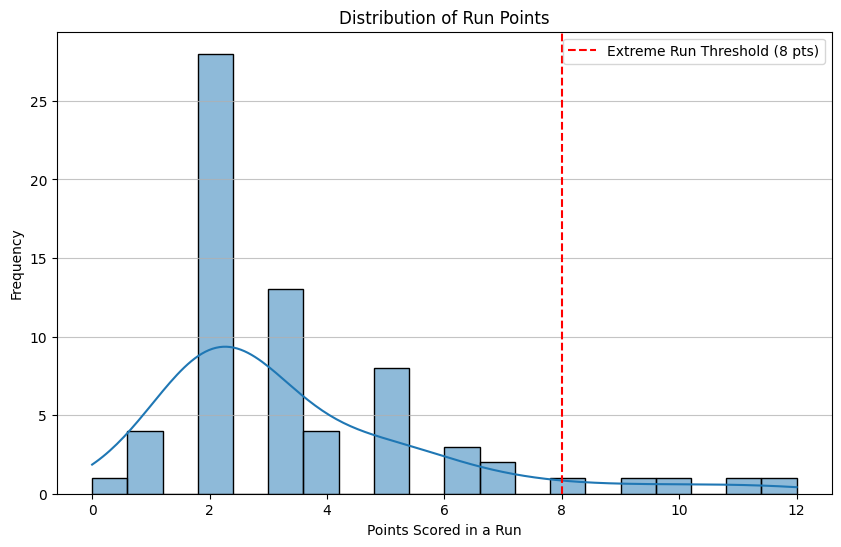

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(runs['pts'], bins=20, kde=True)
plt.axvline(x=extreme_threshold, color='red', linestyle='--', label=f'Extreme Run Threshold ({extreme_threshold} pts)')
plt.title('Distribution of Run Points')
plt.xlabel('Points Scored in a Run')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
weighted_runs = point_filter2(game_id=GAME_ID)

# Top 10 of the largest weighted runs
top_weighted_runs = weighted_runs.sort_values("weighted_pts", ascending=False).head(10)
print("Top 10 weighted runs of the match:")
print(top_weighted_runs[["SCORER", "weighted_pts", "start_min", "end_min", "n_events"]].rename(
    columns={
        "SCORER": "Équipe",
        "weighted_pts": "Points pondérés",
        "start_min": "Début (min)",
        "end_min": "Fin (min)",
        "n_events": "Nb actions"
    })
.round(2))

Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Top 10 weighted runs of the match:
     Équipe  Points pondérés  Début (min)  Fin (min)  Nb actions
67     HOME             12.0        35.47      36.82           6
5      HOME              9.0         2.85       3.93           5
48  VISITOR              9.0        26.33      27.38           5
59     HOME              8.5        31.40      32.98           9
40  VISITOR              8.0        21.65      22.43           7
43     HOME              7.5        23.44      24.13           5
38  VISITOR              7.0        20.30      21.22           6
2   VISITOR              6.5         1.25       1.88           6
50  VISITOR        

In [ ]:
# Druns with >= 10 weighted points "extreme weighted runs".
extreme_weighted_threshold = 10

# Filter runs that meet the extreme threshold
extreme_weighted_runs = weighted_runs[weighted_runs['weighted_pts'] >= extreme_weighted_threshold]

total_weighted_runs_count = len(weighted_runs)
extreme_weighted_runs_count = len(extreme_weighted_runs)
probability_extreme_weighted_run = extreme_weighted_runs_count / total_weighted_runs_count if total_weighted_runs_count > 0 else 0

print(f"Total weighted runs analyzed: {total_weighted_runs_count}")
print(f"Number of extreme weighted runs (>= {extreme_weighted_threshold} weighted points): {extreme_weighted_runs_count}")
print(f"Probability of observing an extreme weighted run: {probability_extreme_weighted_run:.4f}")

Total weighted runs analyzed: 96
Number of extreme weighted runs (>= 10 weighted points): 1
Probability of observing an extreme weighted run: 0.0104


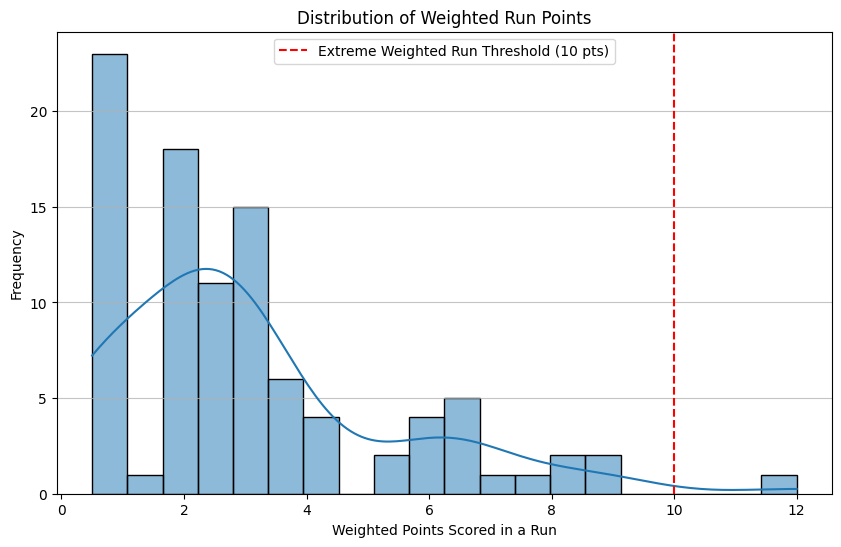

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(weighted_runs['weighted_pts'], bins=20, kde=True)
plt.axvline(x=extreme_weighted_threshold, color='red', linestyle='--', label=f'Extreme Weighted Run Threshold ({extreme_weighted_threshold} pts)')
plt.title('Distribution of Weighted Run Points')
plt.xlabel('Weighted Points Scored in a Run')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Analyzing game ID: 0022301198...
Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Analyzing game ID: 0022301182...
Nombre d'actions : 474
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'i

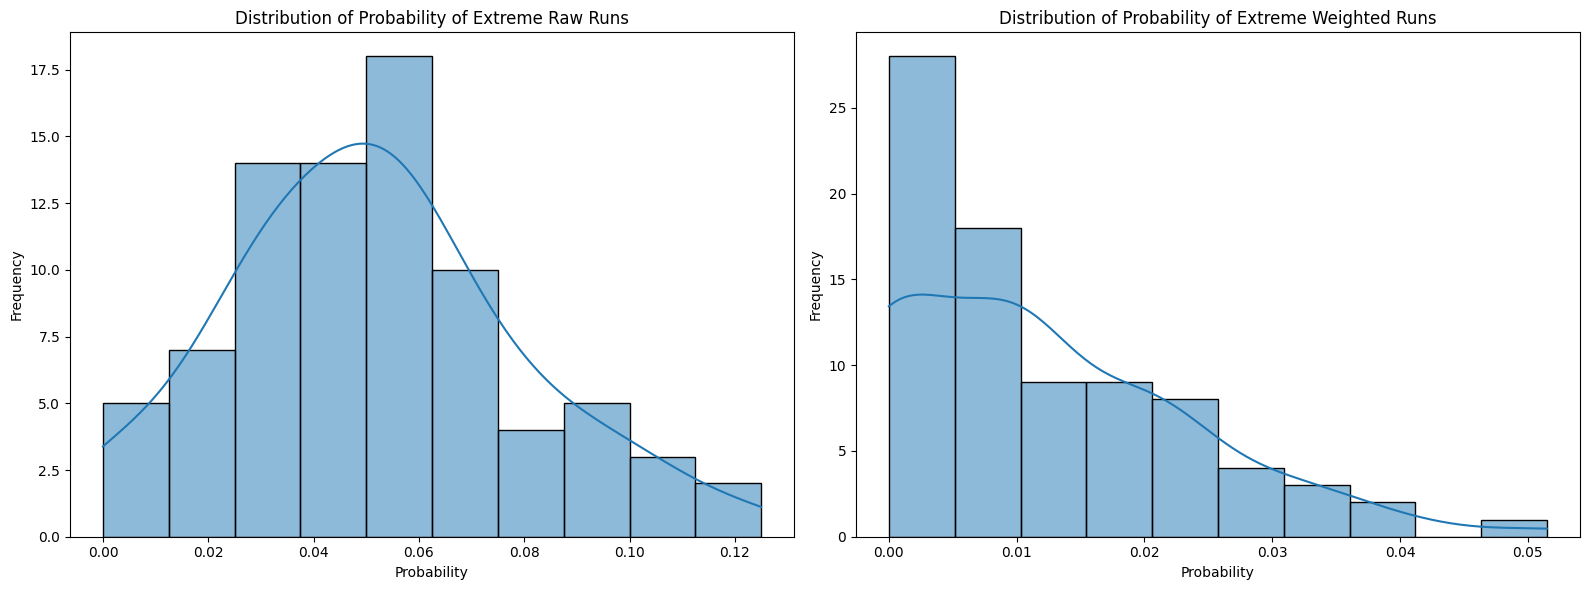

In [ ]:
full_analysis_summary = analysis_extreme_run(SEASON, TEAM_ID)
full_analysis_summary["prob_extreme_raw_run"] = pd.to_numeric(full_analysis_summary["prob_extreme_raw_run"])
full_analysis_summary["prob_extreme_weighted_run"] = pd.to_numeric(full_analysis_summary["prob_extreme_weighted_run"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for probability of extreme raw runs
sns.histplot(full_analysis_summary['prob_extreme_raw_run'], bins=10, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Probability of Extreme Raw Runs')
axes[0].set_xlabel('Probability')
axes[0].set_ylabel('Frequency')

# Histogram for probability of extreme weighted runs
sns.histplot(full_analysis_summary['prob_extreme_weighted_run'], bins=10, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Probability of Extreme Weighted Runs')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

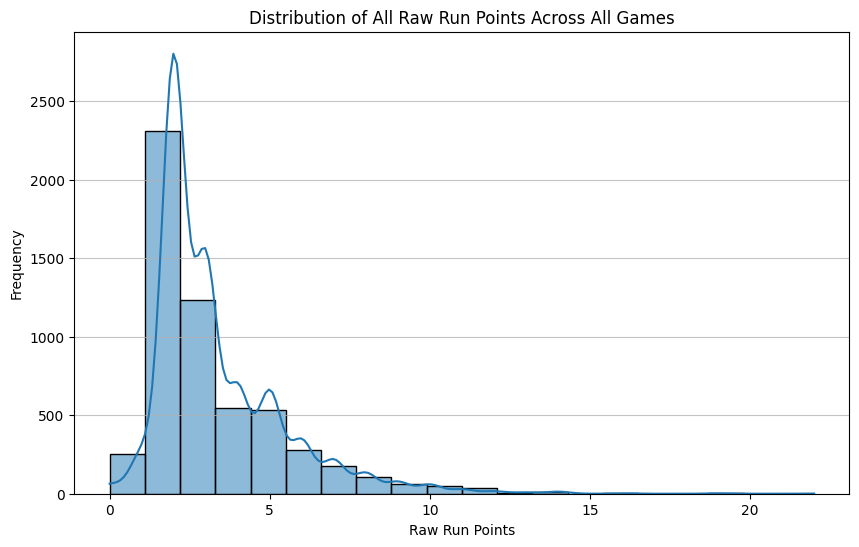

In [ ]:
# 1. Extract all raw run point distributions and flatten them into a single list
all_raw_run_points = [point for sublist in full_analysis_summary['raw_run_points_distribution'] for point in sublist if sublist is not None]

# 2. Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(all_raw_run_points, bins=20, kde=True)

# 3. Set the title of the plot
plt.title('Distribution of All Raw Run Points Across All Games')

# 4. Label the x-axis and y-axis
plt.xlabel('Raw Run Points')
plt.ylabel('Frequency')

# Add grid for better readability
plt.grid(axis='y', alpha=0.75)

# 5. Display the plot
plt.show()


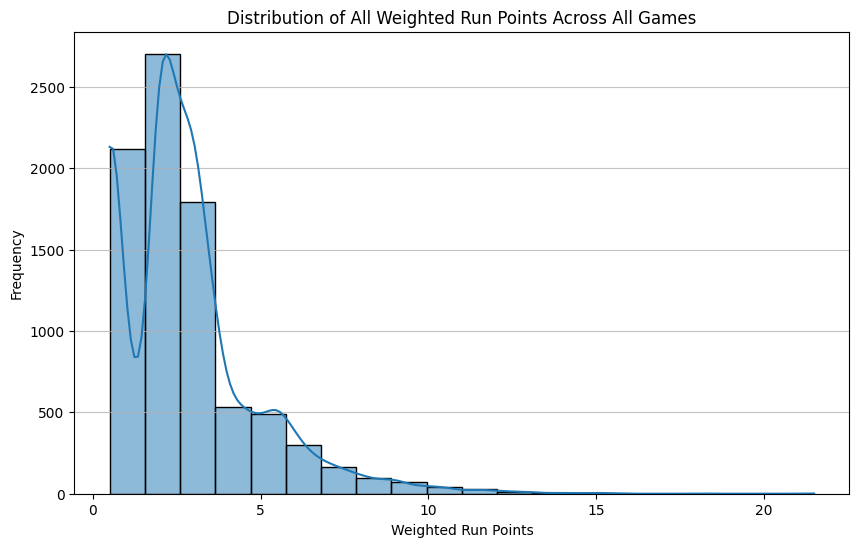

In [ ]:
# 1. Extract all weighted run point distributions and flatten them into a single list
all_weighted_run_points = [point for sublist in full_analysis_summary['weighted_run_points_distribution'] for point in sublist if sublist is not None]

# 2. Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(all_weighted_run_points, bins=20, kde=True)

# 3. Set the title of the plot
plt.title('Distribution of All Weighted Run Points Across All Games')

# 4. Label the x-axis and y-axis
plt.xlabel('Weighted Run Points')
plt.ylabel('Frequency')

# Add grid for better readability
plt.grid(axis='y', alpha=0.75)

# 5. Display the plot
plt.show()

In [ ]:
print(full_analysis_summary.head())

       gameId  ...                   weighted_run_points_distribution
0  0022301198  ...  [2.0, 2.0, 6.5, 2.0, 0.5, 9.0, 6.5, 3.0, 2.0, ...
1  0022301182  ...  [0.5, 3.0, 4.0, 2.0, 2.5, 0.5, 1.0, 0.5, 0.5, ...
2  0022301169  ...  [3.0, 0.5, 3.0, 3.0, 0.5, 1.0, 2.0, 3.5, 0.5, ...
3  0022301155  ...  [3.5, 0.5, 4.0, 6.0, 3.0, 4.5, 0.5, 0.5, 3.5, ...
4  0022301142  ...  [3.5, 2.0, 2.5, 0.5, 3.0, 4.5, 2.5, 3.5, 2.0, ...

[5 rows x 11 columns]


#### Fisher–Tippett–Gnedenko theorem
According to this theorem, both distributions should be in one of the three families : Gumbel, Fréchet and Weibull families

In [86]:
print("Fitting GEV distribution to all raw run points...")
c_raw, loc_raw, scale_raw = fit_gev_distribution(all_raw_run_points)
print(f"GEV parameters for raw run points: Shape={c_raw:.4f}, Location={loc_raw:.4f}, Scale={scale_raw:.4f}")

print("\nFitting GEV distribution to all weighted run points...")
c_weighted, loc_weighted, scale_weighted = fit_gev_distribution(all_weighted_run_points)
print(f"GEV parameters for weighted run points: Shape={c_weighted:.4f}, Location={loc_weighted:.4f}, Scale={scale_weighted:.4f}")

Fitting GEV distribution to all raw run points...
GEV parameters for raw run points: Shape=-0.1371, Location=2.4415, Scale=1.2515

Fitting GEV distribution to all weighted run points...
GEV parameters for weighted run points: Shape=-0.1281, Location=1.8223, Scale=1.3704


The Generalized Extreme Value (GEV) distribution was fitted to `all_raw_run_points`, yielding the following parameters:
*   Shape: -0.1371
*   Location: 2.4415
*   Scale: 1.2515

The GEV distribution was also fitted to `all_weighted_run_points`, resulting in these parameters:
*   Shape: -0.1281
*   Location: 1.8223
*   Scale: 1.3704

Comparing the two distributions, the `all_weighted_run_points` show a lower location parameter (1.8223 vs 2.4415), suggesting a shift towards smaller extreme values, and a slightly higher scale parameter (1.3704 vs 1.2515), indicating a broader spread of extreme values compared to the `all_raw_run_points`.

Further analysis could involve plotting the fitted GEV distributions against the histograms of both raw and weighted run points to visually assess the goodness of fit and understand the implications of these parameter differences on the tail behavior of the data.


We will now visualize the GEV fit for both raw and weighted run points by plotting histograms and overlaying the corresponding probability density functions. Then, interpret the shape parameters of the fitted GEV distributions to determine if they resemble Fréchet, Weibull, or Gumbel distributions.

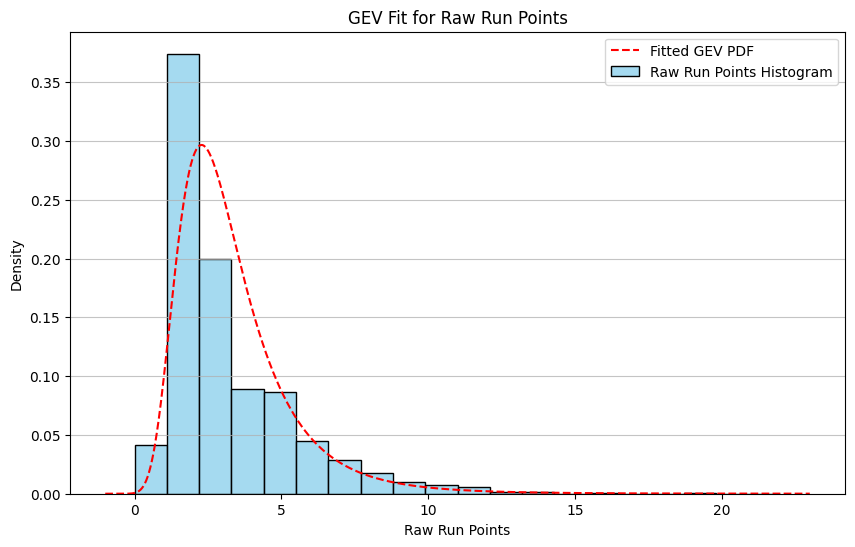

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the histogram of all_raw_run_points
sns.histplot(all_raw_run_points, bins=20, kde=False, stat='density', color='skyblue', label='Raw Run Points Histogram')

# Generate x-values for plotting the PDF
x = np.linspace(min(all_raw_run_points) - 1, max(all_raw_run_points) + 1, 1000)

# Calculate the PDF values for the GEV distribution
pdf_raw = genextreme.pdf(x, c_raw, loc=loc_raw, scale=scale_raw)

plt.plot(x, pdf_raw, color='red', linestyle='--', label='Fitted GEV PDF')

plt.title('GEV Fit for Raw Run Points')
plt.xlabel('Raw Run Points')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)

plt.show()

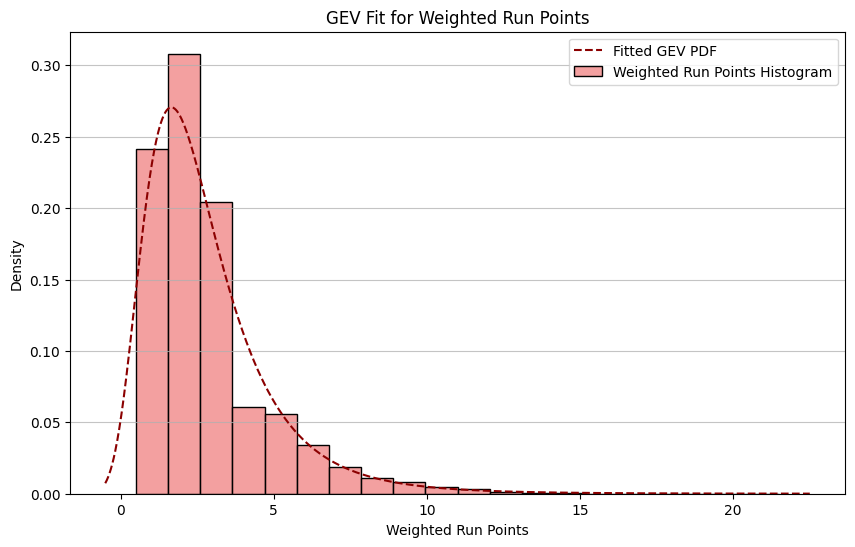

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(all_weighted_run_points, bins=20, kde=False, stat='density', color='lightcoral', label='Weighted Run Points Histogram')

# Generate x-values for plotting the PDF
x_weighted = np.linspace(min(all_weighted_run_points) - 1, max(all_weighted_run_points) + 1, 1000)

# Calculate the PDF values for the GEV distribution
pdf_weighted = genextreme.pdf(x_weighted, c_weighted, loc=loc_weighted, scale=scale_weighted)

# Plot the GEV PDF curve
plt.plot(x_weighted, pdf_weighted, color='darkred', linestyle='--', label='Fitted GEV PDF')

plt.title('GEV Fit for Weighted Run Points')
plt.xlabel('Weighted Run Points')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)

plt.show()

In [ ]:
upper_limit_raw = loc_raw - scale_raw / c_raw
print(f"Theoretical upper limit for raw run points: {upper_limit_raw:.4f}")

Theoretical upper limit for raw run points: 11.5727


### Q2 — Test de Kolmogorov-Smirnov pour l'indépendance des runs

Pour évaluer si les runs peuvent être considérés comme indépendants, nous allons utiliser le test de Kolmogorov-Smirnov à deux échantillons. Bien que ce test ne prouve pas directement l'indépendance sérielle (comme le ferait un test d'autocorrélation), il permet de vérifier si la distribution des runs reste stable au cours du temps. Si les distributions des runs de la première moitié des données sont similaires à celles de la seconde moitié, cela peut renforcer l'hypothèse d'un processus sous-jacent stable, une condition nécessaire pour l'indépendance.

In [54]:
from scipy.stats import ks_2samp
import numpy as np

# --- Raw Run Points ---
# Diviser les points de runs bruts en deux moitiés
mid_point_raw = len(all_raw_run_points) // 2
first_half_raw_runs = all_raw_run_points[:mid_point_raw]
second_half_raw_runs = all_raw_run_points[mid_point_raw:]

# Exécuter le test de Kolmogorov-Smirnov
statistic_raw_ks, p_value_raw_ks = ks_2samp(first_half_raw_runs, second_half_raw_runs)

print(f"--- Test K-S pour les runs bruts ---")
print(f"Statistique K-S: {statistic_raw_ks:.4f}")
print(f"Valeur p: {p_value_raw_ks:.4f}")

# Interprétation
alpha = 0.05
if p_value_raw_ks > alpha:
    print(f"Au seuil de signification de {alpha}, nous ne rejetons pas l'hypothèse nulle.")
    print("Les deux moitiés des runs bruts semblent être tirées de la même distribution.")
else:
    print(f"Au seuil de signification de {alpha}, nous rejetons l'hypothèse nulle.")
    print("Les deux moitiés des runs bruts semblent être tirées de distributions différentes.")

# --- Weighted Run Points ---
# Diviser les points de runs pondérés en deux moitiés
mid_point_weighted = len(all_weighted_run_points) // 2
first_half_weighted_runs = all_weighted_run_points[:mid_point_weighted]
second_half_weighted_runs = all_weighted_run_points[mid_point_weighted:]

# Exécuter le test de Kolmogorov-Smirnov
statistic_weighted_ks, p_value_weighted_ks = ks_2samp(first_half_weighted_runs, second_half_weighted_runs)

print(f"\n--- Test K-S pour les runs pondérés ---")
print(f"Statistique K-S: {statistic_weighted_ks:.4f}")
print(f"Valeur p: {p_value_weighted_ks:.4f}")

# Interprétation
if p_value_weighted_ks > alpha:
    print(f"Au seuil de signification de {alpha}, nous ne rejetons pas l'hypothèse nulle.")
    print("Les deux moitiés des runs pondérés semblent être tirées de la même distribution.")
else:
    print(f"Au seuil de signification de {alpha}, nous rejetons l'hypothèse nulle.")
    print("Les deux moitiés des runs pondérés semblent être tirées de distributions différentes.")

--- Test K-S pour les runs bruts ---
Statistique K-S: 0.0255
Valeur p: 0.3126
Au seuil de signification de 0.05, nous ne rejetons pas l'hypothèse nulle.
Les deux moitiés des runs bruts semblent être tirées de la même distribution.

--- Test K-S pour les runs pondérés ---
Statistique K-S: 0.0093
Valeur p: 0.9933
Au seuil de signification de 0.05, nous ne rejetons pas l'hypothèse nulle.
Les deux moitiés des runs pondérés semblent être tirées de la même distribution.


In [56]:
# Let's start by getting game IDs for GSW for a previous season, for example, 2022-23.

SEASON_PREVIOUS = "2022-23"
TEAM_ID_GSW = gsw["id"]

df_games_previous_season = get_games_played(TEAM_ID_GSW, SEASON_PREVIOUS)
print(f"Matchs récupérés pour la saison {SEASON_PREVIOUS}: {len(df_games_previous_season)}")
df_games_previous_season[["Game_ID", "GAME_DATE", "MATCHUP", "WL", "PTS"]].head(10)

Matchs récupérés pour la saison 2022-23: 82


,Game_ID,GAME_DATE,MATCHUP,WL,PTS
0,0022201230,"APR 09, 2023",GSW @ POR,W,157
1,0022201211,"APR 07, 2023",GSW @ SAC,W,119
2,0022201187,"APR 04, 2023",GSW vs. OKC,W,136
3,0022201175,"APR 02, 2023",GSW @ DEN,L,110
4,0022201158,"MAR 31, 2023",GSW vs. SAS,W,130
5,0022201135,"MAR 28, 2023",GSW vs. NOP,W,120
6,0022201121,"MAR 26, 2023",GSW vs. MIN,L,96
7,0022201103,"MAR 24, 2023",GSW vs. PHI,W,120
8,0022201086,"MAR 22, 2023",GSW @ DAL,W,127
9,0022201074,"MAR 20, 2023",GSW @ HOU,W,121


In [58]:
from scipy.stats import ks_2samp

# --- Raw Run Points Comparison ---
statistic_raw_seasonal_ks, p_value_raw_seasonal_ks = ks_2samp(all_raw_run_points, all_raw_run_points_previous_season)

print(f"--- Test K-S pour les runs bruts (Saison {SEASON} vs. Saison {SEASON_PREVIOUS}) ---")
print(f"Statistique K-S: {statistic_raw_seasonal_ks:.4f}")
print(f"Valeur p: {p_value_raw_seasonal_ks:.4f}")

alpha = 0.05
if p_value_raw_seasonal_ks > alpha:
    print(f"Au seuil de signification de {alpha}, nous ne rejetons pas l'hypothèse nulle.")
    print(f"Les distributions des runs bruts pour la saison {SEASON} et la saison {SEASON_PREVIOUS} semblent être similaires.")
else:
    print(f"Au seuil de signification de {alpha}, nous rejetons l'hypothèse nulle.")
    print(f"Les distributions des runs bruts pour la saison {SEASON} et la saison {SEASON_PREVIOUS} semblent être différentes.")

# --- Weighted Run Points Comparison ---
statistic_weighted_seasonal_ks, p_value_weighted_seasonal_ks = ks_2samp(all_weighted_run_points, all_weighted_run_points_previous_season)

print(f"\n--- Test K-S pour les runs pondérés (Saison {SEASON} vs. Saison {SEASON_PREVIOUS}) ---")
print(f"Statistique K-S: {statistic_weighted_seasonal_ks:.4f}")
print(f"Valeur p: {p_value_weighted_seasonal_ks:.4f}")

if p_value_weighted_seasonal_ks > alpha:
    print(f"Au seuil de signification de {alpha}, nous ne rejetons pas l'hypothèse nulle.")
    print(f"Les distributions des runs pondérés pour la saison {SEASON} et la saison {SEASON_PREVIOUS} semblent être similaires.")
else:
    print(f"Au seuil de signification de {alpha}, nous rejetons l'hypothèse nulle.")
    print(f"Les distributions des runs pondérés pour la saison {SEASON} et la saison {SEASON_PREVIOUS} semblent être différentes.")

--- Test K-S pour les runs bruts (Saison 2023-24 vs. Saison 2022-23) ---
Statistique K-S: 0.0084
Valeur p: 0.9869
Au seuil de signification de 0.05, nous ne rejetons pas l'hypothèse nulle.
Les distributions des runs bruts pour la saison 2023-24 et la saison 2022-23 semblent être similaires.

--- Test K-S pour les runs pondérés (Saison 2023-24 vs. Saison 2022-23) ---
Statistique K-S: 0.0043
Valeur p: 1.0000
Au seuil de signification de 0.05, nous ne rejetons pas l'hypothèse nulle.
Les distributions des runs pondérés pour la saison 2023-24 et la saison 2022-23 semblent être similaires.


### Q3 — Est-ce que la distribution des runs varie énormément selon la saison?

In [57]:
# Perform the full extreme run analysis for the previous season
full_analysis_summary_previous_season = analysis_extreme_run(SEASON_PREVIOUS, TEAM_ID_GSW)
full_analysis_summary_previous_season["prob_extreme_raw_run"] = pd.to_numeric(full_analysis_summary_previous_season["prob_extreme_raw_run"])
full_analysis_summary_previous_season["prob_extreme_weighted_run"] = pd.to_numeric(full_analysis_summary_previous_season["prob_extreme_weighted_run"])

# Extract all raw run point distributions and flatten them into a single list for the previous season
all_raw_run_points_previous_season = [point for sublist in full_analysis_summary_previous_season['raw_run_points_distribution'] for point in sublist if sublist is not None]

# Extract all weighted run point distributions and flatten them into a single list for the previous season
all_weighted_run_points_previous_season = [point for sublist in full_analysis_summary_previous_season['weighted_run_points_distribution'] for point in sublist if sublist is not None]

print(f"Number of raw runs for {SEASON_PREVIOUS}: {len(all_raw_run_points_previous_season)}")
print(f"Number of weighted runs for {SEASON_PREVIOUS}: {len(all_weighted_run_points_previous_season)}")

Analyzing game ID: 0022201230...
Nombre d'actions : 474
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Nombre d'actions : 474
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Analyzing game ID: 0022201211...
Nombre d'actions : 505
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'i

### Q5 — Loi de runs maximums d'une équipe lors d'un match ? Est-ce que c'est indépendant d'un match à un autre ? Est-ce que ça varie selon les saisons ?

#### A. Loi de runs maximums d'une équipe lors d'un match

As previously discussed, we've fitted Generalized Extreme Value (GEV) distributions to the maximum raw and weighted run points observed per game. This uses the Block Maxima Method of Extreme Value Theory.

**For Maximum Raw Run Points (2023-24 Season):**

*   **GEV Parameters (from cell `WzApKZiHepQV`):**
    *   Shape (c): `c_max_raw = -0.0103`
    *   Location (loc): `loc_max_raw = 9.8642`
    *   Scale (scale): `scale_max_raw = 2.0675`
*   **Interpretation:** A shape parameter `c` close to zero implies a distribution that behaves similarly to a **Gumbel distribution**. This means there is no strict theoretical upper limit to the maximum raw run observed in a game, but the probabilities of observing increasingly large maximum runs decrease exponentially.

**For Maximum Weighted Run Points (2023-24 Season):**

*   **GEV Parameters (from cell `BX3H04Y4hf9o`):**
    *   Shape (c): `c_max_weighted = 0.0288`
    *   Location (loc): `loc_max_weighted = 9.8054`
    *   Scale (scale): `scale_max_weighted = 2.0241`
*   **Interpretation:** A positive shape parameter `c` indicates a **Fréchet distribution**. This is a heavy-tailed distribution with **no upper bound**. This means there is no theoretical limit to how large the maximum weighted run in a game can be, and the likelihood of observing very large maximum weighted runs decreases more slowly compared to a Gumbel-like distribution.

#### B. Indépendance des runs maximums d'un match à un autre (au sein d'une saison)

Nous utilisons le test de Kolmogorov-Smirnov à deux échantillons pour vérifier si la distribution des runs maximums reste stable au cours d'une saison.

In [59]:
from scipy.stats import ks_2samp

# --- Max Raw Run Points ---
mid_point_max_raw = len(max_raw_run_points) // 2
first_half_max_raw_runs = max_raw_run_points[:mid_point_max_raw]
second_half_max_raw_runs = max_raw_run_points[mid_point_max_raw:]

statistic_max_raw_ks, p_value_max_raw_ks = ks_2samp(first_half_max_raw_runs, second_half_max_raw_runs)

print(f"--- Test K-S pour les max runs bruts (au sein de la saison {SEASON}) ---")
print(f"Statistique K-S: {statistic_max_raw_ks:.4f}")
print(f"Valeur p: {p_value_max_raw_ks:.4f}")

alpha = 0.05
if p_value_max_raw_ks > alpha:
    print(f"Au seuil de signification de {alpha}, nous ne rejetons pas l'hypothèse nulle.")
    print("Les deux moitiés des max runs bruts semblent être tirées de la même distribution.")
else:
    print(f"Au seuil de signification de {alpha}, nous rejetons l'hypothèse nulle.")
    print("Les deux moitiés des max runs bruts semblent être tirées de distributions différentes.")

# --- Max Weighted Run Points ---
mid_point_max_weighted = len(max_weighted_run_points) // 2
first_half_max_weighted_runs = max_weighted_run_points[:mid_point_max_weighted]
second_half_max_weighted_runs = max_weighted_run_points[mid_point_max_weighted:]

statistic_max_weighted_ks, p_value_max_weighted_ks = ks_2samp(first_half_max_weighted_runs, second_half_max_weighted_runs)

print(f"\n--- Test K-S pour les max runs pondérés (au sein de la saison {SEASON}) ---")
print(f"Statistique K-S: {statistic_max_weighted_ks:.4f}")
print(f"Valeur p: {p_value_max_weighted_ks:.4f}")

if p_value_max_weighted_ks > alpha:
    print(f"Au seuil de signification de {alpha}, nous ne rejetons pas l'hypothèse nulle.")
    print("Les deux moitiés des max runs pondérés semblent être tirées de la même distribution.")
else:
    print(f"Au seuil de signification de {alpha}, nous rejetons l'hypothèse nulle.")
    print("Les deux moitiés des max runs pondérés semblent être tirées de distributions différentes.")

--- Test K-S pour les max runs bruts (au sein de la saison 2023-24) ---
Statistique K-S: 0.1220
Valeur p: 0.9257
Au seuil de signification de 0.05, nous ne rejetons pas l'hypothèse nulle.
Les deux moitiés des max runs bruts semblent être tirées de la même distribution.

--- Test K-S pour les max runs pondérés (au sein de la saison 2023-24) ---
Statistique K-S: 0.1463
Valeur p: 0.7789
Au seuil de signification de 0.05, nous ne rejetons pas l'hypothèse nulle.
Les deux moitiés des max runs pondérés semblent être tirées de la même distribution.


#### C. Variation des runs maximums selon les saisons

Nous allons comparer les distributions des runs maximums entre la saison {SEASON} et la saison {SEASON_PREVIOUS}.

In [60]:
max_raw_run_points_previous_season = [
    max(runs_list) for runs_list in full_analysis_summary_previous_season['raw_run_points_distribution']
    if runs_list and len(runs_list) > 0
]

max_weighted_run_points_previous_season = [
    max(runs_list) for runs_list in full_analysis_summary_previous_season['weighted_run_points_distribution']
    if runs_list and len(runs_list) > 0
]

# --- Max Raw Run Points Comparison (Between Seasons) ---
statistic_max_raw_seasonal_ks, p_value_max_raw_seasonal_ks = ks_2samp(max_raw_run_points, max_raw_run_points_previous_season)

print(f"--- Test K-S pour les max runs bruts (Saison {SEASON} vs. Saison {SEASON_PREVIOUS}) ---")
print(f"Statistique K-S: {statistic_max_raw_seasonal_ks:.4f}")
print(f"Valeur p: {p_value_max_raw_seasonal_ks:.4f}")

alpha = 0.05
if p_value_max_raw_seasonal_ks > alpha:
    print(f"Au seuil de signification de {alpha}, nous ne rejetons pas l'hypothèse nulle.")
    print(f"Les distributions des max runs bruts pour la saison {SEASON} et la saison {SEASON_PREVIOUS} semblent être similaires.")
else:
    print(f"Au seuil de signification de {alpha}, nous rejetons l'hypothèse nulle.")
    print(f"Les distributions des max runs bruts pour la saison {SEASON} et la saison {SEASON_PREVIOUS} semblent être différentes.")

# --- Max Weighted Run Points Comparison (Between Seasons) ---
statistic_max_weighted_seasonal_ks, p_value_max_weighted_seasonal_ks = ks_2samp(max_weighted_run_points, max_weighted_run_points_previous_season)

print(f"\n--- Test K-S pour les max runs pondérés (Saison {SEASON} vs. Saison {SEASON_PREVIOUS}) ---")
print(f"Statistique K-S: {statistic_max_weighted_seasonal_ks:.4f}")
print(f"Valeur p: {p_value_max_weighted_seasonal_ks:.4f}")

if p_value_max_weighted_seasonal_ks > alpha:
    print(f"Au seuil de signification de {alpha}, nous ne rejetons pas l'hypothèse nulle.")
    print(f"Les distributions des max runs pondérés pour la saison {SEASON} et la saison {SEASON_PREVIOUS} semblent être similaires.")
else:
    print(f"Au seuil de signification de {alpha}, nous rejetons l'hypothèse nulle.")
    print(f"Les distributions des max runs pondérés pour la saison {SEASON} et la saison {SEASON_PREVIOUS} semblent être différentes.")

--- Test K-S pour les max runs bruts (Saison 2023-24 vs. Saison 2022-23) ---
Statistique K-S: 0.0488
Valeur p: 1.0000
Au seuil de signification de 0.05, nous ne rejetons pas l'hypothèse nulle.
Les distributions des max runs bruts pour la saison 2023-24 et la saison 2022-23 semblent être similaires.

--- Test K-S pour les max runs pondérés (Saison 2023-24 vs. Saison 2022-23) ---
Statistique K-S: 0.0610
Valeur p: 0.9983
Au seuil de signification de 0.05, nous ne rejetons pas l'hypothèse nulle.
Les distributions des max runs pondérés pour la saison 2023-24 et la saison 2022-23 semblent être similaires.


The problem of our current modelisation is that we are only looking at the distribution of all runs, without distinguishing between "normal" runs and "extreme" runs. In reality, the distribution of extreme runs (e.g., runs with 8 or more points) may differ significantly from the distribution of all runs. By fitting a GEV distribution to all runs, we may be underestimating the tail behavior and thus the probability of observing extreme runs.

In [ ]:
# To address the issue of underestimating the tail behavior by fitting GEV to all runs,
# we fit the GEV distribution only to the extreme runs (e.g., runs with >= 8 points for raw, >= 10 for weighted).

extreme_threshold_raw = 8
extreme_threshold_weighted = 10

extreme_raw_run_points = [p for p in all_raw_run_points if p >= extreme_threshold_raw]
extreme_weighted_run_points = [p for p in all_weighted_run_points if p >= extreme_threshold_weighted]

print(f"Number of extreme raw runs (>= {extreme_threshold_raw}): {len(extreme_raw_run_points)}")
print(f"Number of extreme weighted runs (>= {extreme_threshold_weighted}): {len(extreme_weighted_run_points)}")

if len(extreme_raw_run_points) > 0:
    print("Fitting GEV distribution to extreme raw run points...")
    c_extreme_raw, loc_extreme_raw, scale_extreme_raw = fit_gev_distribution(extreme_raw_run_points)
    print(f"GEV parameters for extreme raw run points: Shape={c_extreme_raw:.4f}, Location={loc_extreme_raw:.4f}, Scale={scale_extreme_raw:.4f}")
else:
    print("No extreme raw runs found.")

if len(extreme_weighted_run_points) > 0:
    print("Fitting GEV distribution to extreme weighted run points...")
    c_extreme_weighted, loc_extreme_weighted, scale_extreme_weighted = fit_gev_distribution(extreme_weighted_run_points)
    print(f"GEV parameters for extreme weighted run points: Shape={c_extreme_weighted:.4f}, Location={loc_extreme_weighted:.4f}, Scale={scale_extreme_weighted:.4f}")
else:
    print("No extreme weighted runs found.")

Number of extreme raw runs (>= 8): 277
Number of extreme weighted runs (>= 10): 95
Fitting GEV distribution to extreme raw run points...
GEV parameters for extreme raw run points: Shape=-6.7081, Location=8.0003, Scale=0.0021
Fitting GEV distribution to extreme weighted run points...
GEV parameters for extreme weighted run points: Shape=-0.6463, Location=10.5338, Scale=0.7359


In [ ]:
max_raw_run_points = [
    max(runs_list) for runs_list in full_analysis_summary['raw_run_points_distribution']
    if runs_list and len(runs_list) > 0
]

# Fit GEV distribution to the maximum raw run points
c_max_raw, loc_max_raw, scale_max_raw = fit_gev_distribution(max_raw_run_points)

print("\nGEV parameters for Maximum Raw Run Points:")
print(f"  Shape (c): {c_max_raw:.4f}")
print(f"  Location (loc): {loc_max_raw:.4f}")
print(f"  Scale (scale): {scale_max_raw:.4f}")


GEV parameters for Maximum Raw Run Points:
  Shape (c): -0.0103
  Location (loc): 9.8642
  Scale (scale): 2.0675


In [ ]:
upper_limit_max_raw = loc_max_raw - scale_max_raw / c_max_raw
print(f"Theoretical upper limit for raw run points: {upper_limit_max_raw:.4f}")

Theoretical upper limit for raw run points: 211.2651


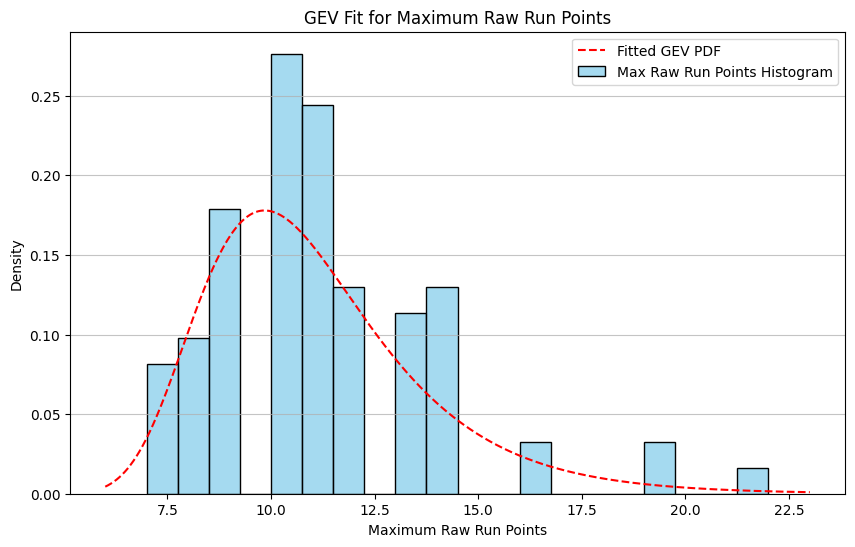

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(max_raw_run_points, bins=20, kde=False, stat='density', color='skyblue', label='Max Raw Run Points Histogram')

x_max_raw = np.linspace(min(max_raw_run_points) - 1, max(max_raw_run_points) + 1, 1000)
pdf_max_raw = genextreme.pdf(x_max_raw, c_max_raw, loc=loc_max_raw, scale=scale_max_raw)

plt.plot(x_max_raw, pdf_max_raw, color='red', linestyle='--', label='Fitted GEV PDF')

plt.title('GEV Fit for Maximum Raw Run Points')
plt.xlabel('Maximum Raw Run Points')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
max_weighted_run_points = [
    max(runs_list) for runs_list in full_analysis_summary['weighted_run_points_distribution']
    if runs_list and len(runs_list) > 0
]

# Fit GEV distribution to the maximum raw run points
c_max_weighted, loc_max_weighted, scale_max_weighted = fit_gev_distribution(max_raw_run_points)

print("\nGEV parameters for Maximum Raw Run Points:")
print(f"  Shape (c): {c_max_weighted:.4f}")
print(f"  Location (loc): {loc_max_weighted:.4f}")
print(f"  Scale (scale): {scale_max_weighted:.4f}")


GEV parameters for Maximum Raw Run Points:
  Shape (c): -0.0103
  Location (loc): 9.8642
  Scale (scale): 2.0675


In [ ]:
upper_limit_max_weighted = loc_max_weighted - scale_max_weighted / c_max_weighted
print(f"Theoretical upper limit for weighted run points: {upper_limit_weighted:.4f}")

Theoretical upper limit for weighted run points: 12.5203


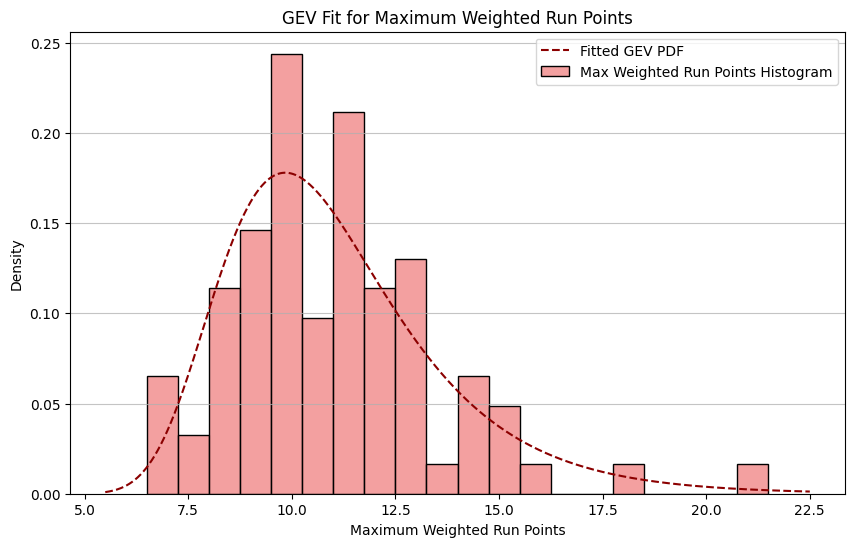

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(max_weighted_run_points, bins=20, kde=False, stat='density', color='lightcoral', label='Max Weighted Run Points Histogram')

x_max_weighted = np.linspace(min(max_weighted_run_points) - 1, max(max_weighted_run_points) + 1, 1000)
pdf_max_weighted = genextreme.pdf(x_max_weighted, c_max_weighted, loc=loc_max_weighted, scale=scale_max_weighted)

plt.plot(x_max_weighted, pdf_max_weighted, color='darkred', linestyle='--', label='Fitted GEV PDF')

plt.title('GEV Fit for Maximum Weighted Run Points')
plt.xlabel('Maximum Weighted Run Points')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

To have another point of view of the question of distribution of the longest run, we can also explore the "Peaks Over Threshold" (POT) method using the Generalized Pareto Distribution (GPD).

In [ ]:
threshold_90th_percentile = np.percentile(all_raw_run_points, 90)
print(f"90th percentile threshold for raw run points: {threshold_90th_percentile:.4f}")

exceedances_raw = [point for point in all_raw_run_points if point > threshold_90th_percentile]
print(f"Number of raw run points exceeding the 90th percentile: {len(exceedances_raw)}")

90th percentile threshold for raw run points: 6.0000
Number of raw run points exceeding the 90th percentile: 452


In [ ]:
shape_gpd, loc_gpd, scale_gpd = genpareto.fit(exceedances_raw)

print(f"Fitted GPD Parameters for Raw Run Exceedances (over {threshold_90th_percentile:.2f}):")
print(f"  Shape (c): {shape_gpd:.4f}")
print(f"  Location (loc): {loc_gpd:.4f}")
print(f"  Scale (scale): {scale_gpd:.4f}")

Fitted GPD Parameters for Raw Run Exceedances (over 6.00):
  Shape (c): 0.7642
  Location (loc): 7.0000
  Scale (scale): 0.5764


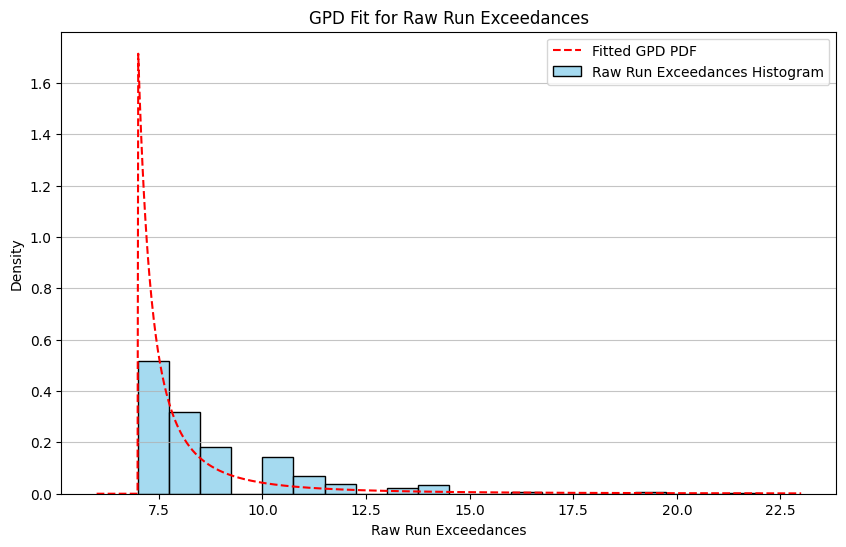

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(exceedances_raw, bins=20, kde=False, stat='density', color='skyblue', label='Raw Run Exceedances Histogram')

x_gpd = np.linspace(min(exceedances_raw) - 1, max(exceedances_raw) + 1, 1000)

pdf_gpd = genpareto.pdf(x_gpd, shape_gpd, loc=loc_gpd, scale=scale_gpd)

plt.plot(x_gpd, pdf_gpd, color='red', linestyle='--', label='Fitted GPD PDF')

plt.title('GPD Fit for Raw Run Exceedances')
plt.xlabel('Raw Run Exceedances')
plt.ylabel('Density')

plt.legend()

plt.grid(axis='y', alpha=0.75)

plt.show()

We have fitted the Generalized Pareto Distribution (GPD) to the raw run exceedances, i.e., those raw run points that exceeded the 90th percentile threshold (`threshold_90th_percentile = 6.0`). The fitted GPD parameters are:

*   **Shape (c):** `shape_gpd = 0.7642`
*   **Location (loc):** `loc_gpd = 7.0000`
*   **Scale (scale):** `scale_gpd = 0.5764`

The **shape parameter `c` ** of the GPD is crucial for understanding the tail behavior of the distribution of exceedances:

*   **If `c > 0` (as observed here, `0.7642`):** The distribution has a **heavy tail** and is unbounded above. This means that extremely large observations (raw run points) are possible, and their probability decays slowly. There is no theoretical upper limit to the raw run points when modeling the exceedances with a GPD with a positive shape parameter.
*   If `c = 0` (Exponential distribution): The tail is lighter, decaying exponentially.
*   If `c < 0`: The distribution has a finite upper bound.

Our `shape_gpd` of `0.7642` indicates a heavy-tailed distribution for the raw run exceedances. This directly addresses the observation that some raw run points exceeded the GEV's theoretical upper limit.

Previously, when fitting the GEV distribution to *all* raw run points, we found a shape parameter `c_raw = -0.1371`. A negative shape parameter in GEV implies a finite upper bound (`11.5727`). The discrepancy arises because the GEV was fitted to the entire dataset of run points, which includes many smaller values.

However, the GPD, specifically designed for modeling exceedances over a high threshold (Peaks Over Threshold method), provides a different picture for the *extreme* tail. The positive `shape_gpd` suggests that once a run crosses a certain threshold (e.g., 6 points in our case), its potential to grow even larger is not limited by a finite ceiling. This explains why we observed raw runs significantly higher than the GEV's theoretical limit (e.g., `max_observed_raw_run = 22.0`). The GEV, when applied to the full dataset, might underestimate the true potential for extreme events because it tries to fit the entire distribution, including the bulk, which can mask the true nature of the very far tail.

Thus, the GPD model with `c > 0` is more appropriate for describing the *extreme* tail behavior of raw runs, especially since it aligns with the empirical observation of runs exceeding the GEV's derived upper bound. It acknowledges the possibility of truly exceptional runs.

The **scale parameter `scale_gpd = 0.5764`** (or `σ`) indicates the spread or variability of the exceedances *above* the threshold. A larger scale parameter would imply that the exceedances are more dispersed, meaning there's a wider range of values for extreme events. A smaller scale parameter, as observed here, suggests that the exceedances, while heavy-tailed, are relatively concentrated around the location parameter once they cross the threshold. It essentially controls how quickly the probabilities of exceedances decrease as values get larger.


1.  **Unbounded Extremes**: The positive shape parameter (`shape_gpd > 0`) strongly suggests that raw run points in NBA games do not have a theoretical maximum. While very high runs are rare, the model indicates that even larger runs are always theoretically possible, with probabilities that diminish slowly.
2.  **Better Tail Representation**: The GPD, when applied to exceedances, provides a more accurate representation of the *extreme* tail behavior compared to a GEV model fitted to the entire distribution. This is crucial for understanding and predicting truly rare and impactful events.
3.  **Variability of Extremes**: The scale parameter quantifies the spread of these extreme runs, offering insight into how much variability there is among these large values.

In essence, while the GEV provided a first look, the GPD analysis refined our understanding of the most extreme raw runs, indicating a heavier, unbounded tail. This suggests that record-breaking runs are always a statistical possibility, although with decreasing likelihood as the run size increases.

In [ ]:
threshold_90th_percentile_weighted = np.percentile(all_weighted_run_points, 90)
print(f"90th percentile threshold for weighted run points: {threshold_90th_percentile_weighted:.4f}")

exceedances_weighted = [point for point in all_weighted_run_points if point > threshold_90th_percentile_weighted]
print(f"Number of weighted run points exceeding the 90th percentile: {len(exceedances_weighted)}")


shape_gpd_weighted, loc_gpd_weighted, scale_gpd_weighted = genpareto.fit(exceedances_weighted)

print(f"\nFitted GPD Parameters for Weighted Run Exceedances (over {threshold_90th_percentile_weighted:.2f}):")
print(f"  Shape (c): {shape_gpd_weighted:.4f}")
print(f"  Location (loc): {loc_gpd_weighted:.4f}")
print(f"  Scale (scale): {scale_gpd_weighted:.4f}")

plt.figure(figsize=(10, 6))

sns.histplot(exceedances_weighted, bins=20, kde=False, stat='density', color='lightcoral', label='Weighted Run Exceedances Histogram')

x_gpd_weighted = np.linspace(min(exceedances_weighted) - 1, max(exceedances_weighted) + 1, 1000)

pdf_gpd_weighted = genpareto.pdf(x_gpd_weighted, shape_gpd_weighted, loc=loc_gpd_weighted, scale=scale_gpd_weighted)

plt.plot(x_gpd_weighted, pdf_gpd_weighted, color='darkred', linestyle='--', label='Fitted GPD PDF')

plt.title('GPD Fit for Weighted Run Exceedances')
plt.xlabel('Weighted Run Exceedances')
plt.ylabel('Density')

plt.legend()

plt.grid(axis='y', alpha=0.75)

plt.show()

## Partie II : Etude des écarts de points et Distribution des écarts de points à l'issue d'un match

### H1 : Plot la variation des scores tout au long d'un match

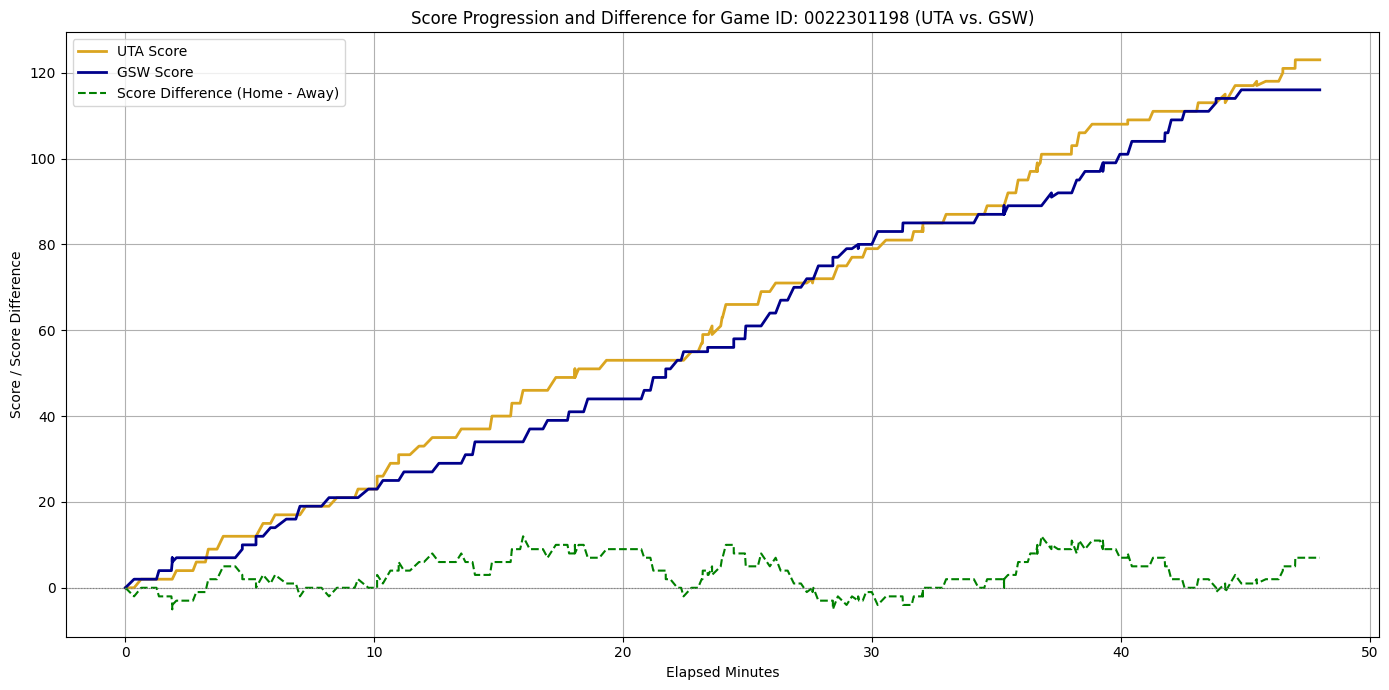

Interpretation of the plot:
- The yellow line represents the score of the home team (UTA).
- The dark blue line represents the score of the away team (GSW).
- The green dashed line shows the score difference (Home - Away). Positive values mean UTA is leading, negative values mean GSW is leading.
- The plot helps visualize momentum shifts, lead changes, and the overall trajectory of the game score.


In [61]:
# Ensure the DataFrame is sorted by elapsed time
df_sorted = df.sort_values(by='ELAPSED_MINUTES')

# Create the plot
plt.figure(figsize=(14, 7))

# Plot Home Score
plt.plot(df_sorted['ELAPSED_MINUTES'], df_sorted['SCORE_HOME'], label=f'{home_team} Score', color='goldenrod', linewidth=2)
# Plot Away Score
plt.plot(df_sorted['ELAPSED_MINUTES'], df_sorted['SCORE_VISITOR'], label=f'{away_team} Score', color='darkblue', linewidth=2)

# Plot Score Difference (Home - Away)
# We need to calculate the score difference for each timestamp
df_sorted['SCORE_DIFFERENCE'] = df_sorted['SCORE_HOME'] - df_sorted['SCORE_VISITOR']
plt.plot(df_sorted['ELAPSED_MINUTES'], df_sorted['SCORE_DIFFERENCE'], label='Score Difference (Home - Away)', color='green', linestyle='--', linewidth=1.5)

# Add horizontal line at 0 for score difference clarity
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)

plt.title(f'Score Progression and Difference for Game ID: {GAME_ID} ({home_team} vs. {away_team})')
plt.xlabel('Elapsed Minutes')
plt.ylabel('Score / Score Difference')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Interpretation of the plot:")
print(f"- The yellow line represents the score of the home team ({home_team}).")
print(f"- The dark blue line represents the score of the away team ({away_team}).")
print(f"- The green dashed line shows the score difference (Home - Away). Positive values mean {home_team} is leading, negative values mean {away_team} is leading.")
print(f"- The plot helps visualize momentum shifts, lead changes, and the overall trajectory of the game score.")

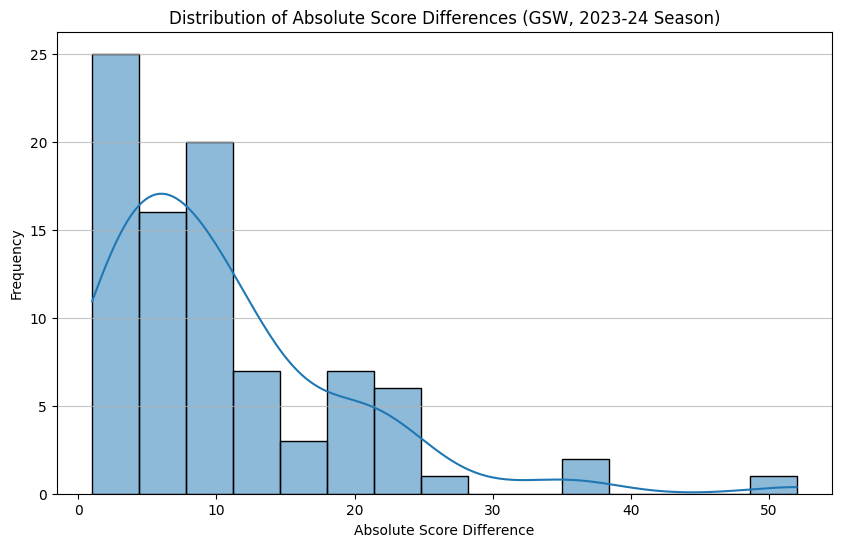

Blowout threshold (90th percentile of absolute score differences): 22.00 points
Number of games qualifying as blowouts (>=22.00 points): 10
Percentage of blowout games: 11.36%


In [66]:
from nba_api.stats.endpoints import leaguegamefinder

# Fetch games using LeagueGameFinder to get PLUS_MINUS which is point differential
gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=TEAM_ID, season_nullable=SEASON)
df_games = gamefinder.get_data_frames()[0]

# The LeagueGameFinder result (`df_games`) should directly contain 'PLUS_MINUS'
if 'PLUS_MINUS' in df_games.columns:
    df_games['SCORE_DIFFERENCE'] = abs(df_games['PLUS_MINUS'])
elif 'PTS' in df_games.columns and 'PTS_OPP' in df_games.columns:
    # Fallback if PLUS_MINUS is somehow missing, using own points and opponent points
    df_games['SCORE_DIFFERENCE'] = abs(df_games['PTS'] - df_games['PTS_OPP'])
else:
    print("Error: Neither 'PLUS_MINUS' nor 'PTS' and 'PTS_OPP' are available in the game log data from leaguegamefinder.")
    print("Available columns:", df_games.columns.tolist())
    raise KeyError("Required columns for score difference calculation are missing.")

plt.figure(figsize=(10, 6))
sns.histplot(df_games['SCORE_DIFFERENCE'], bins=15, kde=True)
plt.title('Distribution of Absolute Score Differences (GSW, 2023-24 Season)')
plt.xlabel('Absolute Score Difference')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

blowout_threshold = np.percentile(df_games['SCORE_DIFFERENCE'], 90)
num_blowouts = df_games[df_games['SCORE_DIFFERENCE'] >= blowout_threshold].shape[0]

print(f"Blowout threshold (90th percentile of absolute score differences): {blowout_threshold:.2f} points")
print(f"Number of games qualifying as blowouts (>={blowout_threshold:.2f} points): {num_blowouts}")
print(f"Percentage of blowout games: {(num_blowouts / len(df_games) * 100):.2f}%")


Number of blowout scores (>= 22.00 points): 10

GEV parameters for Blowout Scores:
  Shape (c): -6.5637
  Location (loc): 22.3029
  Scale (scale): 1.9882


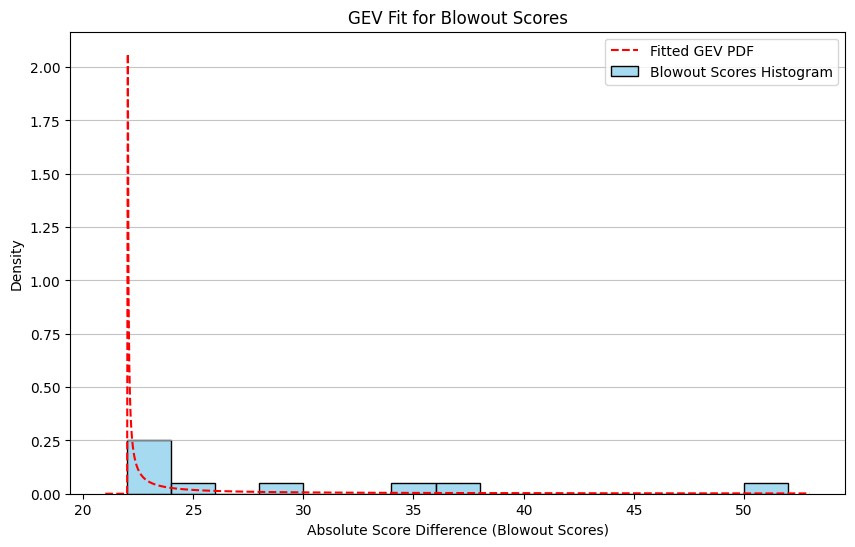

In [67]:
blowout_scores = df_games[df_games['SCORE_DIFFERENCE'] >= blowout_threshold]['SCORE_DIFFERENCE']

print(f"Number of blowout scores (>= {blowout_threshold:.2f} points): {len(blowout_scores)}")

c_blowout, loc_blowout, scale_blowout = fit_gev_distribution(blowout_scores)

print("\nGEV parameters for Blowout Scores:")
print(f"  Shape (c): {c_blowout:.4f}")
print(f"  Location (loc): {loc_blowout:.4f}")
print(f"  Scale (scale): {scale_blowout:.4f}")

plt.figure(figsize=(10, 6))
sns.histplot(blowout_scores, bins=15, kde=False, stat='density', color='skyblue', label='Blowout Scores Histogram')

x_blowout = np.linspace(min(blowout_scores) - 1, max(blowout_scores) + 1, 1000)
pdf_blowout = genextreme.pdf(x_blowout, c_blowout, loc=loc_blowout, scale=scale_blowout)

plt.plot(x_blowout, pdf_blowout, color='red', linestyle='--', label='Fitted GEV PDF')

plt.title('GEV Fit for Blowout Scores')
plt.xlabel('Absolute Score Difference (Blowout Scores)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

In [68]:
runs['duration'] = runs['end_min'] - runs['start_min']
print("Calculated durations for raw runs:")
print(runs[['pts', 'start_min', 'end_min', 'duration']].head())

Calculated durations for raw runs:
    pts  start_min   end_min  duration
0   0.0   0.350000  0.350000  0.000000
1   2.0   0.633333  0.633333  0.000000
2   5.0   1.350000  1.883333  0.533333
3  10.0   2.050000  3.933333  1.883333
4   5.0   4.700000  5.250000  0.550000


In [74]:
weighted_runs['speed'] = weighted_runs['weighted_pts'] / weighted_runs['duration']
weighted_runs['speed'] = weighted_runs['speed'].replace([np.inf, -np.inf], np.nan)

print("Calculated speeds for weighted runs:")
print(weighted_runs[['weighted_pts', 'duration', 'speed']].head())

zero_duration_weighted_runs_speed = weighted_runs[weighted_runs['duration'] == 0]
if not zero_duration_weighted_runs_speed.empty:
    print(f"\nFound {len(zero_duration_weighted_runs_speed)} weighted runs with zero duration. Their speed values are now NaN.")
    print(zero_duration_weighted_runs_speed[['weighted_pts', 'duration', 'speed']].head())
else:
    print("\nNo weighted runs with zero duration found for speed calculation.")

Calculated speeds for weighted runs:
   weighted_pts  duration      speed
0           2.0  0.000000        NaN
1           2.0  0.000000        NaN
2           6.5  0.633333  10.263158
3           2.0  0.000000        NaN
4           0.5  0.000000        NaN

Found 48 weighted runs with zero duration. Their speed values are now NaN.
   weighted_pts  duration  speed
0           2.0       0.0    NaN
1           2.0       0.0    NaN
3           2.0       0.0    NaN
4           0.5       0.0    NaN
7           3.0       0.0    NaN


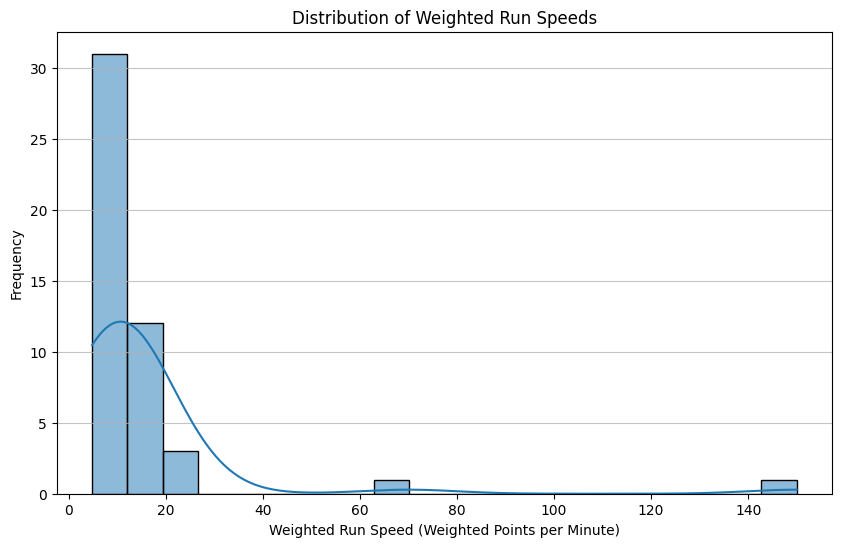

In [75]:
plt.figure(figsize=(10, 6))
sns.histplot(weighted_runs['speed'].dropna(), bins=20, kde=True)
plt.title('Distribution of Weighted Run Speeds')
plt.xlabel('Weighted Run Speed (Weighted Points per Minute)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

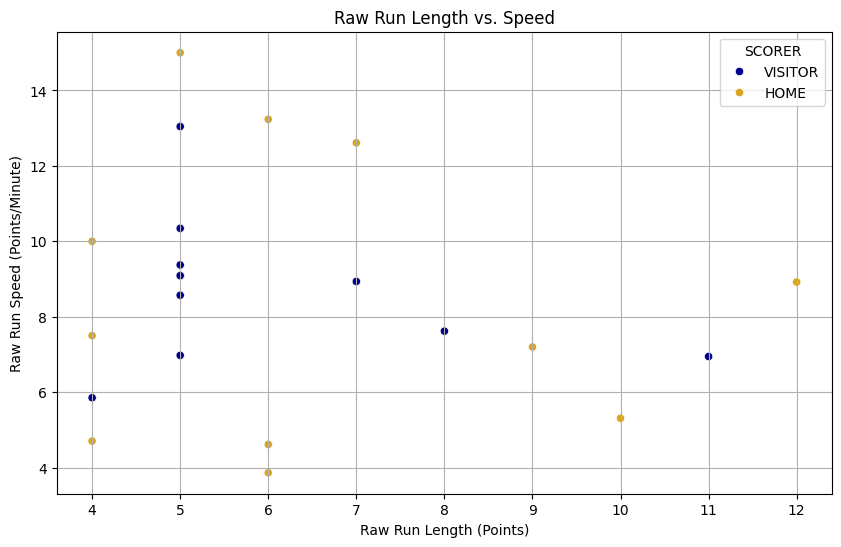

In [76]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=runs.dropna(subset=['speed']), x='pts', y='speed', hue='SCORER', palette={'HOME': 'goldenrod', 'VISITOR': 'darkblue'})
plt.title('Raw Run Length vs. Speed')
plt.xlabel('Raw Run Length (Points)')
plt.ylabel('Raw Run Speed (Points/Minute)')
plt.grid(True)
plt.show()

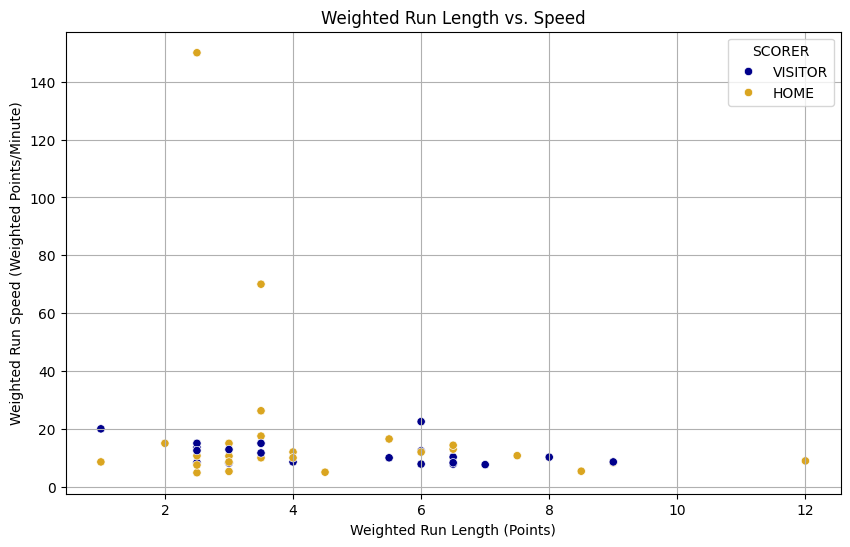

In [77]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=weighted_runs.dropna(subset=['speed']), x='weighted_pts', y='speed', hue='SCORER', palette={'HOME': 'goldenrod', 'VISITOR': 'darkblue'})
plt.title('Weighted Run Length vs. Speed')
plt.xlabel('Weighted Run Length (Points)')
plt.ylabel('Weighted Run Speed (Weighted Points/Minute)')
plt.grid(True)
plt.show()

In [78]:
runs['speed'] = runs['pts'] / runs['duration']
runs['speed'] = runs['speed'].replace([np.inf, -np.inf], np.nan)

print("Calculated speeds for raw runs:")
print(runs[['pts', 'duration', 'speed']].head())

zero_duration_raw_runs_speed = runs[runs['duration'] == 0]

if not zero_duration_raw_runs_speed.empty:
    print(f"\nFound {len(zero_duration_raw_runs_speed)} raw runs with zero duration. Their speed values are now NaN.")
    print(zero_duration_raw_runs_speed[['pts', 'duration', 'speed']].head())
else:
    print("\nNo raw runs with zero duration found for speed calculation.")

Calculated speeds for raw runs:
    pts  duration     speed
0   0.0  0.000000       NaN
1   2.0  0.000000       NaN
2   5.0  0.533333  9.375000
3  10.0  1.883333  5.309735
4   5.0  0.550000  9.090909

Found 46 raw runs with zero duration. Their speed values are now NaN.
   pts  duration  speed
0  0.0       0.0    NaN
1  2.0       0.0    NaN
5  3.0       0.0    NaN
6  2.0       0.0    NaN
7  2.0       0.0    NaN


## Define Comeback Simulation Function

### Subtask:
Develop a Python function that simulates future game states given a current score difference (x points) and remaining time (y minutes). This function will use the previously derived distributions of raw/weighted run points and their durations/speeds to model how scores might evolve. It will determine if the trailing team manages to take the lead by the end of the simulated game.


In [79]:
import pandas as pd
import numpy as np
import random

def simulate_game_state(current_score_difference, remaining_time, run_type='raw', num_simulations=1):
    """
    Simulates future game states given a current score difference and remaining time.
    Uses previously derived distributions of run points and durations to model score evolution.

    Args:
        current_score_difference (float): The initial score difference (leading_score - trailing_score).
                                          Must be a positive value, indicating the leading team's advantage.
        remaining_time (float): The initial remaining time in minutes.
        run_type (str): Type of runs to use ('raw' or 'weighted'). Defaults to 'raw'.
        num_simulations (int): Number of simulations to run.

    Returns:
        tuple: (list of bools indicating comeback, list of final score differences)
               A comeback is True if the initially trailing team ends up winning.
               Final score difference is (leading_team_final_score - trailing_team_final_score).
    """

    if run_type == 'raw':
        # Filter out runs with duration 0 or points 0, and drop NaNs
        runs_df_filtered = runs.dropna(subset=['duration', 'pts']).copy()
        runs_df_filtered = runs_df_filtered[(runs_df_filtered['duration'] > 0) & (runs_df_filtered['pts'] > 0)]
        points_col = 'pts'
    elif run_type == 'weighted':
        runs_df_filtered = weighted_runs.dropna(subset=['duration', 'weighted_pts']).copy()
        runs_df_filtered = runs_df_filtered[(runs_df_filtered['duration'] > 0) & (runs_df_filtered['weighted_pts'] > 0)]
        points_col = 'weighted_pts'
    else:
        raise ValueError("run_type must be 'raw' or 'weighted'")

    if runs_df_filtered.empty:
        print(f"Warning: No valid runs found for run_type='{run_type}' after filtering. Returning default values.")
        return [False] * num_simulations, [float(current_score_difference)] * num_simulations

    comebacks = []
    final_score_differences = []

    for _ in range(num_simulations):
        sim_remaining_time = float(remaining_time)
        trailing_score_sim = 0.0
        leading_score_sim = float(current_score_difference)

        while sim_remaining_time > 0:
            # Randomly sample a run from the filtered DataFrame
            sampled_run = runs_df_filtered.sample(1).iloc[0]

            run_points = sampled_run[points_col]
            run_duration = sampled_run['duration']

            # If the sampled run's duration is greater than remaining time,
            # scale the points proportionally to fit the remaining time.
            if run_duration > sim_remaining_time:
                run_points = (run_points / run_duration) * sim_remaining_time if run_duration > 0 else 0
                run_duration = sim_remaining_time # The actual time consumed is sim_remaining_time

            # Randomly decide which team scores (trailing or leading)
            # We assume a 50/50 chance for either team to generate a run.
            if random.random() < 0.5: # 50% chance for the trailing team (the one attempting comeback) to score
                trailing_score_sim += run_points
            else: # 50% chance for the leading team (the one holding the lead) to score
                leading_score_sim += run_points

            sim_remaining_time -= run_duration

            # Ensure sim_remaining_time does not go below zero
            if sim_remaining_time < 0:
                sim_remaining_time = 0

        # After simulation, determine if a comeback occurred
        # A comeback is successful if the initially trailing team (trailing_score_sim) ends up with a higher score.
        comeback_successful = (trailing_score_sim > leading_score_sim)
        final_sim_score_difference = leading_score_sim - trailing_score_sim

        comebacks.append(comeback_successful)
        final_score_differences.append(final_sim_score_difference)

    return comebacks, final_score_differences

### Test the Comeback Simulation Function

We will now test the `simulate_game_state` function with an example scenario. Let's consider a situation where the trailing team is down by `10` points with `12` minutes remaining in the game. We will run `100` simulations to estimate the probability of a comeback.

In [80]:
initial_score_difference = 10.0
remaining_time = 12.0
num_simulations = 100

print(f"Simulating {num_simulations} games with an initial score difference of {initial_score_difference} points and {remaining_time} minutes remaining...")

comebacks, final_diffs = simulate_game_state(
    current_score_difference=initial_score_difference,
    remaining_time=remaining_time,
    run_type='raw',
    num_simulations=num_simulations
)

comeback_probability = sum(comebacks) / num_simulations
mean_final_score_difference = np.mean(final_diffs)

print(f"\nProbability of comeback: {comeback_probability:.2%}")
print(f"Average final score difference (leading - trailing): {mean_final_score_difference:.2f} points")

comebacks_weighted, final_diffs_weighted = simulate_game_state(
    current_score_difference=initial_score_difference,
    remaining_time=remaining_time,
    run_type='weighted',
    num_simulations=num_simulations
)

comeback_probability_weighted = sum(comebacks_weighted) / num_simulations
mean_final_score_difference_weighted = np.mean(final_diffs_weighted)

print(f"\nProbability of comeback (weighted runs): {comeback_probability_weighted:.2%}")
print(f"Average final score difference (weighted runs): {mean_final_score_difference_weighted:.2f} points")

Simulating 100 games with an initial score difference of 10.0 points and 12.0 minutes remaining...

Probability of comeback: 44.00%
Average final score difference (leading - trailing): 5.63 points

Probability of comeback (weighted runs): 43.00%
Average final score difference (weighted runs): 5.65 points
